# SES-residualized exposome

This notebook uses the **primary Macrostructure + NODDI harmonized datasets** for the white matter features and General Exposome score, and reads only the socioeconomic metadata needed from the SES sensitivity files.

Current provisional residualization variables: **household income + parental education + Area Deprivation Index (ADI)**. 

In [1]:
import gc
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

ROOT_DIR=Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
RESULTS_DIR=ROOT_DIR/"output_data"/"results"
CODE_DIR=ROOT_DIR/"code"
if str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))

import partial_r as pr
importlib.reload(pr)
from figure_formatting import setup_figure,save_figure

# Reviewer-analysis variables
INCOME_VAR="income"
PEDU_VAR="parental_education"
AREA_VAR="le_l_adi__addr1__national_prcnt"
AREA_LABEL="ADI"
SES_VARS=[INCOME_VAR,PEDU_VAR,AREA_VAR]
TARGET_RESID="General_SES_resid_SES3"
BASE_COVS=["age","sex","t1post_dwi_contrast"]

# Primary files contain General_SES + WM features.
PATH_A_MAIN=RESULTS_DIR/"dfA_macro_plus_NODDI_12_10.csv"
PATH_B_MAIN=RESULTS_DIR/"dfB_macro_plus_NODDI_12_10.csv"

# Sensitivity files contain income, parental education, and ADI.
PATH_A_SES=RESULTS_DIR/"dfA_macro_plus_NODDI_sens_11_30.csv"
PATH_B_SES=RESULTS_DIR/"dfB_macro_plus_NODDI_sens_11_30.csv"

OUT_DIR=RESULTS_DIR/"reviewer_revision"/"exposome_residualized_income_pedu_ADI"
OUT_DIR.mkdir(parents=True,exist_ok=True)

print("Primary Discovery file:",PATH_A_MAIN)
print("Primary Replication file:",PATH_B_MAIN)
print("SES metadata Discovery file:",PATH_A_SES)
print("SES metadata Replication file:",PATH_B_SES)
print("Output directory:",OUT_DIR)


Primary Discovery file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfA_macro_plus_NODDI_12_10.csv
Primary Replication file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfB_macro_plus_NODDI_12_10.csv
SES metadata Discovery file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfA_macro_plus_NODDI_sens_11_30.csv
SES metadata Replication file: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfB_macro_plus_NODDI_sens_11_30.csv
Output directory: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/exposome_residualized_income_pedu_ADI


## 1. Load the primary WM data and attach SES metadata

In [2]:
ID_CANDIDATES=["src_subject_id","subjectkey","participant_id","subject_id","abcd_subject_id"]
CHECK_COLS=["matched_group","age","sex","t1post_dwi_contrast"]

def _headers(path):
    return pd.read_csv(path,nrows=0).columns.tolist()

def _shared_id(main_header,ses_header):
    for c in ID_CANDIDATES:
        if c in main_header and c in ses_header:
            return c
    return None

def _validate_row_alignment(main_meta,ses_meta,split_label):
    if len(main_meta)!=len(ses_meta):
        raise ValueError(f"{split_label}: main and SES files have different retained Ns ({len(main_meta)} vs {len(ses_meta)}).")
    for c in CHECK_COLS:
        if c not in main_meta.columns or c not in ses_meta.columns:
            continue
        a=main_meta[c].to_numpy()
        b=ses_meta[c].to_numpy()
        if pd.api.types.is_numeric_dtype(main_meta[c]) and pd.api.types.is_numeric_dtype(ses_meta[c]):
            ok=np.allclose(a.astype(float),b.astype(float),equal_nan=True)
        else:
            aa=pd.Series(a).astype("string").fillna("<NA>").to_numpy()
            bb=pd.Series(b).astype("string").fillna("<NA>").to_numpy()
            ok=np.array_equal(aa,bb)
        if not ok:
            raise ValueError(f"{split_label}: cannot safely align files by row order; column {c!r} differs.")

def load_split(main_path,ses_path,group_value,split_label,chunksize=750):
    main_header=_headers(main_path)
    ses_header=_headers(ses_path)
    id_col=_shared_id(main_header,ses_header)

    main_required=["matched_group","General_SES",*BASE_COVS]
    ses_required=["matched_group",*SES_VARS]
    missing_main=[c for c in main_required if c not in main_header]
    missing_ses=[c for c in ses_required if c not in ses_header]
    if missing_main:
        raise KeyError(f"Missing from primary file {main_path.name}: {missing_main}")
    if missing_ses:
        raise KeyError(f"Missing from SES file {ses_path.name}: {missing_ses}")

    bundle_raw=[c for c in main_header if c.startswith("bundle_") and not c.endswith("_mean")]
    main_use=list(dict.fromkeys(main_required+CHECK_COLS+([id_col] if id_col else [])+bundle_raw))
    ses_use=list(dict.fromkeys(ses_required+CHECK_COLS+([id_col] if id_col else [])))

    main_parts=[]
    for chunk in pd.read_csv(main_path,usecols=main_use,chunksize=chunksize):
        keep=chunk["matched_group"].eq(group_value)
        if keep.any():
            main_parts.append(chunk.loc[keep])
    main=pd.concat(main_parts,ignore_index=True)
    del main_parts
    gc.collect()

    ses_parts=[]
    for chunk in pd.read_csv(ses_path,usecols=ses_use,chunksize=chunksize):
        keep=chunk["matched_group"].eq(group_value)
        if keep.any():
            ses_parts.append(chunk.loc[keep])
    ses=pd.concat(ses_parts,ignore_index=True)
    del ses_parts
    gc.collect()

    if id_col:
        if main[id_col].duplicated().any() or ses[id_col].duplicated().any():
            raise ValueError(f"{split_label}: duplicate values found in ID column {id_col!r}.")
        ses_small=ses[[id_col,*SES_VARS]].copy()
        n_main=len(main)
        main=main.merge(ses_small,on=id_col,how="left",validate="one_to_one")
        if len(main)!=n_main:
            raise ValueError(f"{split_label}: merge unexpectedly changed row count.")
        print(f"{split_label}: attached SES variables using {id_col!r}.")
    else:
        _validate_row_alignment(main[CHECK_COLS],ses[CHECK_COLS],split_label)
        for c in SES_VARS:
            main[c]=ses[c].to_numpy()
        print(f"{split_label}: no recognized ID column; verified metadata and attached SES variables by row order.")

    del ses
    gc.collect()

    new_cols=[c[:-len("_median")] if c.startswith("bundle_") and c.endswith("_median") else c for c in main.columns]
    idx=pd.Index(new_cols)
    if idx.duplicated().any():
        dup=idx[idx.duplicated()].tolist()
        raise ValueError(f"Duplicate columns after cleaning: {dup[:10]}")
    main.columns=new_cols
    return main

dfA=load_split(PATH_A_MAIN,PATH_A_SES,1,"Discovery")
dfB=load_split(PATH_B_MAIN,PATH_B_SES,2,"Replication")

msmt_cols=[c for c in dfA.columns if c.startswith("bundle_")]
msmt_cols_B=[c for c in dfB.columns if c.startswith("bundle_")]
if set(msmt_cols)!=set(msmt_cols_B):
    raise ValueError("Discovery and replication WM feature sets do not match.")
if msmt_cols!=msmt_cols_B:
    nonbundle=[c for c in dfB.columns if not c.startswith("bundle_")]
    dfB=dfB[nonbundle+msmt_cols]

print("\nDiscovery shape:",dfA.shape)
print("Replication shape:",dfB.shape)
print("WM features:",len(msmt_cols))
print("SES variables present:",{c:(c in dfA.columns and c in dfB.columns) for c in SES_VARS})
if len(msmt_cols)!=1302:
    raise ValueError(f"Expected 1,302 Macrostructure + NODDI features; found {len(msmt_cols)}.")


Discovery: attached SES variables using 'subject_id'.
Replication: attached SES variables using 'subject_id'.

Discovery shape: (4078, 1311)
Replication shape: (4096, 1311)
WM features: 1302
SES variables present: {'income': True, 'parental_education': True, 'le_l_adi__addr1__national_prcnt': True}


## 2. Residualize the General Exposome

Residualization is performed separately in Discovery and Replication. The **before** and **after** WM models will then use the exact same complete-case participants within each split.

In [3]:
def residualize_exposome_inplace(df,split_label):
    required=["General_SES",*SES_VARS,*BASE_COVS]
    n_before=len(df)
    df.dropna(subset=required,inplace=True)
    df.reset_index(drop=True,inplace=True)

    X=sm.add_constant(df[SES_VARS].astype(float),has_constant="add")
    y=df["General_SES"].astype(float)
    fit=sm.OLS(y,X).fit()
    df[TARGET_RESID]=fit.resid.to_numpy()

    print("\n"+"="*60)
    print(split_label)
    print("="*60)
    print(f"N: {n_before:,} -> {len(df):,} complete cases")
    print(f"Variance in General Exposome explained by income + education + {AREA_LABEL}: R²={fit.rsquared:.3f}")
    print(f"Original vs residualized General Exposome: r={df['General_SES'].corr(df[TARGET_RESID]):.3f}")
    print("Residual correlations with residualization variables:")
    print(df[[TARGET_RESID,*SES_VARS]].corr().loc[TARGET_RESID,SES_VARS].round(6))
    return fit

fit_A=residualize_exposome_inplace(dfA,"Discovery")
fit_B=residualize_exposome_inplace(dfB,"Replication")


Discovery
N: 4,078 -> 3,098 complete cases
Variance in General Exposome explained by income + education + ADI: R²=0.825
Original vs residualized General Exposome: r=0.418
Residual correlations with residualization variables:
income                            -0.0
parental_education                -0.0
le_l_adi__addr1__national_prcnt   -0.0
Name: General_SES_resid_SES3, dtype: float64

Replication
N: 4,096 -> 3,123 complete cases
Variance in General Exposome explained by income + education + ADI: R²=0.814
Original vs residualized General Exposome: r=0.431
Residual correlations with residualization variables:
income                            -0.0
parental_education                 0.0
le_l_adi__addr1__national_prcnt    0.0
Name: General_SES_resid_SES3, dtype: float64


## 3. Mass-univariate WM models before and after residualization

Both models adjust for age, sex, and diffusion image quality. The original General Exposome model is rerun on the same SES-complete-case participants used by the residualized model, so attenuation cannot be attributed simply to a change in sample.

In [4]:
print("Running Discovery: original General Exposome...")
before_A=pr.run_partial_r(
    dfA,msmt_cols,BASE_COVS+["General_SES"],
    include_etiv=False,target_cov="General_SES"
)

print("Running Replication: original General Exposome...")
before_B=pr.run_partial_r(
    dfB,msmt_cols,BASE_COVS+["General_SES"],
    include_etiv=False,target_cov="General_SES"
)

print("Running Discovery: SES-residualized General Exposome...")
after_A=pr.run_partial_r(
    dfA,msmt_cols,BASE_COVS+[TARGET_RESID],
    include_etiv=False,target_cov=TARGET_RESID
)

print("Running Replication: SES-residualized General Exposome...")
after_B=pr.run_partial_r(
    dfB,msmt_cols,BASE_COVS+[TARGET_RESID],
    include_etiv=False,target_cov=TARGET_RESID
)

print("[DONE] All four mass-univariate models completed.")

Running Discovery: original General Exposome...
Running Replication: original General Exposome...
Running Discovery: SES-residualized General Exposome...
Running Replication: SES-residualized General Exposome...
[DONE] All four mass-univariate models completed.


## 4. Summarize and save reviewer results

In [5]:
def merge_results(x,y,suffix_x,suffix_y):
    keep=["feature","partial_r","p_fdr"]
    return x[keep].merge(
        y[keep],on="feature",suffixes=(suffix_x,suffix_y),validate="one_to_one"
    )

before_split=merge_results(before_A,before_B,"_A","_B")
after_split=merge_results(after_A,after_B,"_A","_B")
before_after_A=merge_results(before_A,after_A,"_before","_after")
before_after_B=merge_results(before_B,after_B,"_before","_after")

before_split_r=before_split["partial_r_A"].corr(before_split["partial_r_B"])
after_split_r=after_split["partial_r_A"].corr(after_split["partial_r_B"])

before_both_fdr=int(((before_split["p_fdr_A"]<.05)&(before_split["p_fdr_B"]<.05)).sum())
after_both_fdr=int(((after_split["p_fdr_A"]<.05)&(after_split["p_fdr_B"]<.05)).sum())

def split_summary(df_before,df_after,merged,n,fit,split):
    return {
        "split":split,
        "N":n,
        "SES_block_R2":fit.rsquared,
        "mean_abs_r_before":df_before["partial_r"].abs().mean(),
        "mean_abs_r_after":df_after["partial_r"].abs().mean(),
        "mean_abs_delta_r":(merged["partial_r_after"]-merged["partial_r_before"]).abs().mean(),
        "FDR_before":int((df_before["p_fdr"]<.05).sum()),
        "FDR_after":int((df_after["p_fdr"]<.05).sum()),
        "before_after_profile_r":merged["partial_r_before"].corr(merged["partial_r_after"])
    }

summary_df=pd.DataFrame([
    split_summary(before_A,after_A,before_after_A,len(dfA),fit_A,"Discovery"),
    split_summary(before_B,after_B,before_after_B,len(dfB),fit_B,"Replication")
])

split_summary_df=pd.DataFrame([{
    "before_split_r":before_split_r,
    "after_split_r":after_split_r,
    "before_FDR_both":before_both_fdr,
    "after_FDR_both":after_both_fdr
}])

print("\n"+"="*70)
print("BEFORE VS AFTER SES RESIDUALIZATION")
print("="*70)
display(summary_df.round(4))
print(f"\nSplit-half profile r: before={before_split_r:.3f}, after={after_split_r:.3f}")
print(f"FDR-significant in BOTH splits: before={before_both_fdr}, after={after_both_fdr}")

before_A.to_csv(OUT_DIR/"before_residualization_discovery.csv",index=False)
before_B.to_csv(OUT_DIR/"before_residualization_replication.csv",index=False)
after_A.to_csv(OUT_DIR/"after_residualization_discovery.csv",index=False)
after_B.to_csv(OUT_DIR/"after_residualization_replication.csv",index=False)
summary_df.to_csv(OUT_DIR/"residualization_summary.csv",index=False)
split_summary_df.to_csv(OUT_DIR/"residualization_split_summary.csv",index=False)
print("Saved numerical results to:",OUT_DIR)


BEFORE VS AFTER SES RESIDUALIZATION


,split,N,SES_block_R2,mean_abs_r_before,mean_abs_r_after,mean_abs_delta_r,FDR_before,FDR_after,before_after_profile_r
0,Discovery,3098,0.8253,0.091,0.0495,0.0455,1061,782,0.9070
1,Replication,3123,0.8138,0.085,0.0357,0.0527,995,433,0.9063



Split-half profile r: before=0.944, after=0.767
FDR-significant in BOTH splits: before=933, after=387
Saved numerical results to: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/exposome_residualized_income_pedu_ADI


## 5. Final supplementary figure: before vs after residualization

- **A:** Original General Exposome profile, Discovery vs Replication
- **B:** SES-residualized General Exposome profile, Discovery vs Replication
- **C:** Discovery, original vs residualized effects
- **D:** Replication, original vs residualized effects

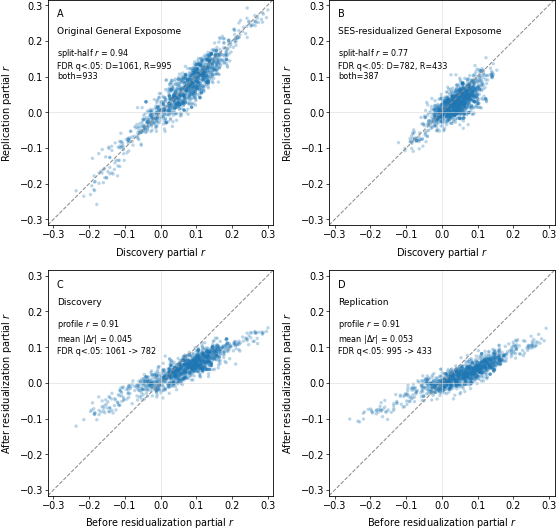

In [10]:
all_r=np.concatenate([
    before_A["partial_r"].to_numpy(),
    before_B["partial_r"].to_numpy(),
    after_A["partial_r"].to_numpy(),
    after_B["partial_r"].to_numpy()
])
all_r=all_r[np.isfinite(all_r)]
lim=np.max(np.abs(all_r))*1.05
n_features=len(after_A)

before_sig_A=int((before_A["p_fdr"]<.05).sum())
before_sig_B=int((before_B["p_fdr"]<.05).sum())
after_sig_A=int((after_A["p_fdr"]<.05).sum())
after_sig_B=int((after_B["p_fdr"]<.05).sum())
before_both=int(((before_split["p_fdr_A"]<.05)&(before_split["p_fdr_B"]<.05)).sum())
after_both=int(((after_split["p_fdr_A"]<.05)&(after_split["p_fdr_B"]<.05)).sum())

fig,axes=setup_figure(
    width_mm=150,height_mm=145,
    base_pt=7,label_pt=7,title_pt=7,
    sans_list=["Arial","DejaVu Sans"],
    axes_linewidth=.6,line_width=.7,
    margins_mm=(14,5,13,6),
    nrows=2,ncols=2,axes_aspect="equal"
)
axes=np.asarray(axes).reshape(2,2)

def style_scatter(ax,x,y):
    ax.scatter(x,y,s=6,alpha=.30,edgecolors="none",rasterized=True)
    ax.plot([-lim,lim],[-lim,lim],"--",linewidth=.75,color=".55")
    ax.axhline(0,linewidth=.4,color=".85")
    ax.axvline(0,linewidth=.4,color=".85")
    ax.set_xlim(-lim,lim)
    ax.set_ylim(-lim,lim)
    ax.set_aspect("equal",adjustable="box")
    ax.tick_params(length=2,width=.5,pad=1.5)

# A: original split-half profile
ax=axes[0,0]
style_scatter(ax,before_split["partial_r_A"],before_split["partial_r_B"])
ax.text(.04,.96,"A",transform=ax.transAxes,ha="left",va="top",fontsize=7)
ax.text(.04,.88,"Original General Exposome",transform=ax.transAxes,ha="left",va="top",fontsize=6.5)
ax.text(
    .04,.79,
    rf"split-half $r$ = {before_split_r:.2f}"+"\n"
    f"FDR q<.05: D={before_sig_A}, R={before_sig_B}\n"
    f"both={before_both}",
    transform=ax.transAxes,ha="left",va="top",fontsize=5.8
)
ax.set_xlabel(r"Discovery partial $r$")
ax.set_ylabel(r"Replication partial $r$")

# B: residualized split-half profile
ax=axes[0,1]
style_scatter(ax,after_split["partial_r_A"],after_split["partial_r_B"])
ax.text(.04,.96,"B",transform=ax.transAxes,ha="left",va="top",fontsize=7)
ax.text(.04,.88,"SES-residualized General Exposome",transform=ax.transAxes,ha="left",va="top",fontsize=6.5)
ax.text(
    .04,.79,
    rf"split-half $r$ = {after_split_r:.2f}"+"\n"
    f"FDR q<.05: D={after_sig_A}, R={after_sig_B}\n"
    f"both={after_both}",
    transform=ax.transAxes,ha="left",va="top",fontsize=5.8
)
ax.set_xlabel(r"Discovery partial $r$")
ax.set_ylabel(r"Replication partial $r$")

# C: Discovery before vs after
disc_map_r=before_after_A["partial_r_before"].corr(before_after_A["partial_r_after"])
disc_delta=(before_after_A["partial_r_after"]-before_after_A["partial_r_before"]).abs().mean()
ax=axes[1,0]
style_scatter(ax,before_after_A["partial_r_before"],before_after_A["partial_r_after"])
ax.text(.04,.96,"C",transform=ax.transAxes,ha="left",va="top",fontsize=7)
ax.text(.04,.88,"Discovery",transform=ax.transAxes,ha="left",va="top",fontsize=6.5)
ax.text(
    .04,.79,
    rf"profile $r$ = {disc_map_r:.2f}"+"\n"
    rf"mean $|\Delta r|$ = {disc_delta:.3f}"+"\n"
    f"FDR q<.05: {before_sig_A} -> {after_sig_A}",
    transform=ax.transAxes,ha="left",va="top",fontsize=5.8
)
ax.set_xlabel(r"Before residualization partial $r$")
ax.set_ylabel(r"After residualization partial $r$")

# D: Replication before vs after
repl_map_r=before_after_B["partial_r_before"].corr(before_after_B["partial_r_after"])
repl_delta=(before_after_B["partial_r_after"]-before_after_B["partial_r_before"]).abs().mean()
ax=axes[1,1]
style_scatter(ax,before_after_B["partial_r_before"],before_after_B["partial_r_after"])
ax.text(.04,.96,"D",transform=ax.transAxes,ha="left",va="top",fontsize=7)
ax.text(.04,.88,"Replication",transform=ax.transAxes,ha="left",va="top",fontsize=6.5)
ax.text(
    .04,.79,
    rf"profile $r$ = {repl_map_r:.2f}"+"\n"
    rf"mean $|\Delta r|$ = {repl_delta:.3f}"+"\n"
    f"FDR q<.05: {before_sig_B} -> {after_sig_B}",
    transform=ax.transAxes,ha="left",va="top",fontsize=5.8
)
ax.set_xlabel(r"Before residualization partial $r$")
ax.set_ylabel(r"After residualization partial $r$")

svg=OUT_DIR/"General_Exposome_before_after_SES_residualization.svg"
pdf=OUT_DIR/"General_Exposome_before_after_SES_residualization.pdf"
png=OUT_DIR/"General_Exposome_before_after_SES_residualization.png"

save_figure(fig,str(svg),autofit=False)
save_figure(fig,str(pdf),autofit=False)
fig.savefig(png,dpi=300)
plt.show()

In [7]:
from statsmodels.stats.multitest import multipletests

def audit_result(df,label):
    assert len(df)==1302,f"{label}: {len(df)} features"
    assert df["feature"].is_unique,f"{label}: duplicate features"

    _,q_check,_,_=multipletests(df["p_value"],method="fdr_bh")
    max_q_diff=np.nanmax(np.abs(q_check-df["p_fdr"].to_numpy()))

    sig=df["p_fdr"]<.05
    raw_cutoff=df.loc[sig,"p_value"].max() if sig.any() else np.nan

    return {
        "model":label,
        "n_features":len(df),
        "mean_abs_r":df["partial_r"].abs().mean(),
        "median_abs_r":df["partial_r"].abs().median(),
        "raw_p_lt_05":int((df["p_value"]<.05).sum()),
        "raw_p_lt_01":int((df["p_value"]<.01).sum()),
        "FDR_q_lt_05":int(sig.sum()),
        "largest_raw_p_surviving_BH":raw_cutoff,
        "max_stored_vs_recomputed_q_diff":max_q_diff
    }

audit_df=pd.DataFrame([
    audit_result(before_A,"Discovery before"),
    audit_result(before_B,"Replication before"),
    audit_result(after_A,"Discovery after"),
    audit_result(after_B,"Replication after")
])
display(audit_df)

assert set(before_A["feature"])==set(before_B["feature"])
assert set(after_A["feature"])==set(after_B["feature"])
assert set(before_A["feature"])==set(after_A["feature"])

fdr_overlap=after_A[["feature","partial_r","p_fdr"]].merge(
    after_B[["feature","partial_r","p_fdr"]],
    on="feature",suffixes=("_A","_B"),validate="one_to_one"
)
fdr_overlap["sig_A"]=fdr_overlap["p_fdr_A"]<.05
fdr_overlap["sig_B"]=fdr_overlap["p_fdr_B"]<.05

both=int((fdr_overlap["sig_A"]&fdr_overlap["sig_B"]).sum())
A_only=int((fdr_overlap["sig_A"]&~fdr_overlap["sig_B"]).sum())
B_only=int((~fdr_overlap["sig_A"]&fdr_overlap["sig_B"]).sum())
neither=int((~fdr_overlap["sig_A"]&~fdr_overlap["sig_B"]).sum())
sign_agreement=np.mean(
    np.sign(fdr_overlap["partial_r_A"])==
    np.sign(fdr_overlap["partial_r_B"])
)

print("\nAfter residualization FDR overlap")
print(f"Both:             {both}")
print(f"Discovery only:   {A_only}")
print(f"Replication only: {B_only}")
print(f"Neither:          {neither}")
print(f"Sign agreement:   {sign_agreement:.3f}")

for label,before,after in [
    ("Discovery",before_A,after_A),
    ("Replication",before_B,after_B)
]:
    before_mean=before["partial_r"].abs().mean()
    after_mean=after["partial_r"].abs().mean()
    print(
        f"{label}: mean |r| {before_mean:.4f} -> {after_mean:.4f} "
        f"({after_mean/before_mean:.1%} retained)"
    )

,model,n_features,mean_abs_r,median_abs_r,raw_p_lt_05,raw_p_lt_01,FDR_q_lt_05,largest_raw_p_surviving_BH,max_stored_vs_recomputed_q_diff
0,Discovery before,1302,0.091030,0.088120,1073,971,1061,0.039637,0.0
1,Replication before,1302,0.085034,0.079653,1010,908,995,0.037057,0.0
2,Discovery after,1302,0.049459,0.046686,843,656,782,0.029141,0.0
3,Replication after,1302,0.035724,0.030411,567,384,433,0.016142,0.0



After residualization FDR overlap
Both:             387
Discovery only:   395
Replication only: 46
Neither:          474
Sign agreement:   0.830
Discovery: mean |r| 0.0910 -> 0.0495 (54.3% retained)
Replication: mean |r| 0.0850 -> 0.0357 (42.0% retained)


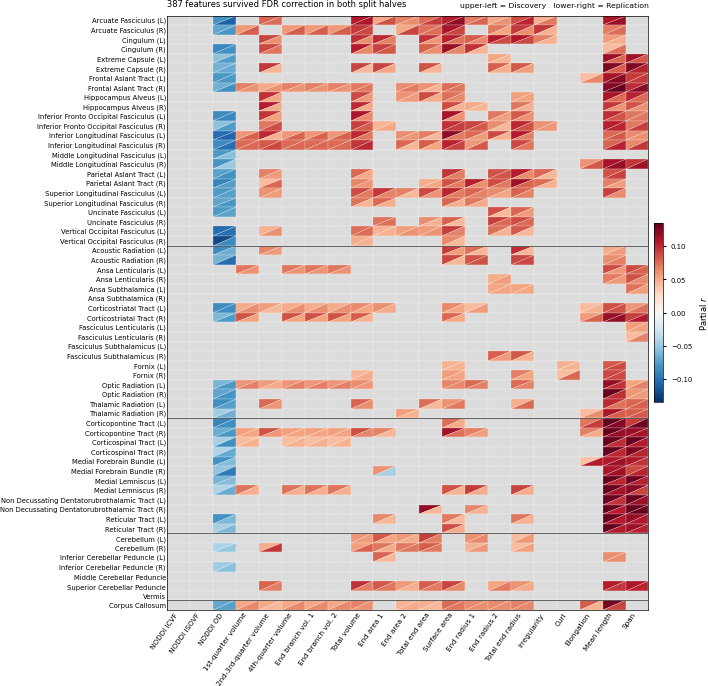

In [11]:
# ------------------------------------------------
# Heatmap: show ONLY exact FDR-replicated features
# ------------------------------------------------
vals=np.concatenate([
    mat_A.to_numpy()[sig_both.to_numpy()],
    mat_B.to_numpy()[sig_both.to_numpy()]
])
vals=vals[np.isfinite(vals)]

vmax=np.nanpercentile(np.abs(vals),98)
norm=TwoSlopeNorm(vmin=-vmax,vcenter=0,vmax=vmax)
cmap=plt.get_cmap("RdBu_r")

fig,ax=setup_figure(
    width_mm=180,height_mm=195,
    base_pt=6,label_pt=6,title_pt=6,
    sans_list=["Arial","DejaVu Sans"],
    axes_linewidth=.5,line_width=.6,
    margins_mm=(42,12,34,10),
    axes_aspect="auto"
)

n_bundles=len(bundle_order)
n_metrics=len(metric_order)

ax.set_xlim(0,n_metrics)
ax.set_ylim(0,n_bundles)
ax.invert_yaxis()

for i,bundle in enumerate(bundle_order):
    for j,metric in enumerate(metric_order):
        # Exact feature must survive FDR independently in BOTH splits
        if not sig_both.loc[bundle,metric]:
            ax.add_patch(plt.Rectangle(
                (j,i),1,1,
                facecolor="gainsboro",
                edgecolor="white",
                linewidth=.15
            ))
            continue

        val_A=mat_A.loc[bundle,metric]
        val_B=mat_B.loc[bundle,metric]

        # Discovery = upper-left triangle
        ax.add_patch(Polygon(
            [(j,i+1),(j,i),(j+1,i)],
            facecolor=cmap(norm(val_A)),
            edgecolor="white",
            linewidth=.15
        ))

        # Replication = lower-right triangle
        ax.add_patch(Polygon(
            [(j+1,i),(j+1,i+1),(j,i+1)],
            facecolor=cmap(norm(val_B)),
            edgecolor="white",
            linewidth=.15
        ))

# separators between bundle classes
previous=type_map[bundle_order[0]]
for i,bundle in enumerate(bundle_order[1:],start=1):
    current=type_map[bundle]
    if current!=previous:
        ax.axhline(i,color=".35",linewidth=.65)
        previous=current

ax.set_xticks(np.arange(n_metrics)+.5)
ax.set_xticklabels(
    [METRIC_LABELS.get(m,m) for m in metric_order],
    rotation=55,ha="right",fontsize=5.2
)

ax.set_yticks(np.arange(n_bundles)+.5)
ax.set_yticklabels(
    [label_map[b] for b in bundle_order],
    fontsize=4.9
)

ax.tick_params(length=0,pad=1)

ax.text(
    0,1.012,
    f"{int(sig_both.to_numpy().sum())} features survived FDR correction in both split halves",
    transform=ax.transAxes,
    ha="left",va="bottom",
    fontsize=6
)

ax.text(
    1,1.012,
    "upper-left = Discovery   lower-right = Replication",
    transform=ax.transAxes,
    ha="right",va="bottom",
    fontsize=5.5
)

sm=ScalarMappable(norm=norm,cmap=cmap)
sm.set_array([])
cbar=fig.colorbar(sm,ax=ax,fraction=.018,pad=.012)
cbar.set_label(r"Partial $r$",fontsize=6)
cbar.ax.tick_params(labelsize=5,length=2)

svg=OUT_DIR/"SES_residualized_replicated_FDR_heatmap.svg"
pdf=OUT_DIR/"SES_residualized_replicated_FDR_heatmap.pdf"
png=OUT_DIR/"SES_residualized_replicated_FDR_heatmap.png"

save_figure(fig,str(svg),autofit=False)
save_figure(fig,str(pdf),autofit=False)
fig.savefig(png,dpi=300)
plt.show()